In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy.stats import norm

In [3]:
df = pd.read_csv('dev.csv')

In [4]:
df['Class'] = df['Class'].map({4: 0, 2: 1})

In [5]:
x = df.drop(['Sample code number', 'Uniformity of Cell Shape', 'Mitoses', 'Class'], axis=1).values
y = df['Class'].values
print(x)
print(y)

[[ 5  1  1 ...  1  3  1]
 [ 5  4  5 ... 10  3  2]
 [ 3  1  1 ...  2  3  1]
 ...
 [ 5 10  3 ...  3  8 10]
 [ 4  8  4 ...  4 10  6]
 [ 4  8  5 ...  5 10  4]]
[1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 0 1 1 0 1 0 0 1 1 0 1 1 1 1 1 1 0 1 1 1 0 1
 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 1 1 0 1 0 0 1
 1 1 1 1 1 1 1 1 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0
 0 1 1 1 0 1 1 1 1 0 0 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 0
 0 1 1 0 1 1 0 0 1 1 1 1 0 0 1 1 1 1 1 0 0 0 1 0 1 0 1 1 1 0 0 1 0 0 0 1 0
 0 1 1 1 1 1 1 1 1 0 0 1 1 1 0 0 1 1 1 0 0 1 0 0 0 1 1 0 1 1 0 0 0 0 1 0 0
 1 0 0 0 1 0 1 0 0 0 0 1 1 1 1 1 1 0 0 1 1 0 1 0 0 0 1 1 1 1 0 0 0 0 0 1 0
 0 0 1 0 1 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 0 1 0 1 0 0 1 1
 0 1 1 1 0 1 1 0 0 1 1 0 1 0 1 1 0 1 0 0 0 1 1 0 0 1 0 1 1 0 0 1 1 1 0 1 1
 1 0 0 1 1 1 0 1 1 0 0 0 0 0 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1 0 1 0 1 1 1 1 0
 1 1 1 0 1 0 1 1 1 

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=24, stratify=y)

In [7]:
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

In [8]:
model = GaussianNB()
model.fit(x_train_sc, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [9]:
# ── 3a. Gaussian Naive Bayes (continuous features) ──────────
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model_name, y_true, y_pred):
    """
    Computes common classification metrics and returns them in a dictionary.
    """
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='weighted'),
        "Recall": recall_score(y_true, y_pred, average='weighted'),
        "F1-Score": f1_score(y_true, y_pred, average='weighted')
    }
    
    # Optional: Print the results immediately
    for key, value in metrics.items():
        if key != "Model":
            print(f"{key}: {value:.4f}")
            
    return metrics

gnb = GaussianNB(var_smoothing=1e-9)
gnb.fit(x_train_sc, y_train)
y_pred_gnb = gnb.predict(x_test_sc)
y_prob_gnb = gnb.predict_proba(x_test_sc)
results_gnb = evaluate_model(
    "Gaussian Naive Bayes", y_test, y_pred_gnb)
print("Class Priors:", dict(zip(
    gnb.classes_, gnb.class_prior_.round(4))))
 


Accuracy: 0.9562
Precision: 0.9570
Recall: 0.9562
F1-Score: 0.9564
Class Priors: {np.int64(0): np.float64(0.3498), np.int64(1): np.float64(0.6502)}


In [10]:
print(classification_report(y_test, y_pred_gnb))
print("Accuracy:", accuracy_score(y_test, y_pred_gnb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gnb))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        48
           1       0.98      0.96      0.97        89

    accuracy                           0.96       137
   macro avg       0.95      0.96      0.95       137
weighted avg       0.96      0.96      0.96       137

Accuracy: 0.9562043795620438
Confusion Matrix:
 [[46  2]
 [ 4 85]]


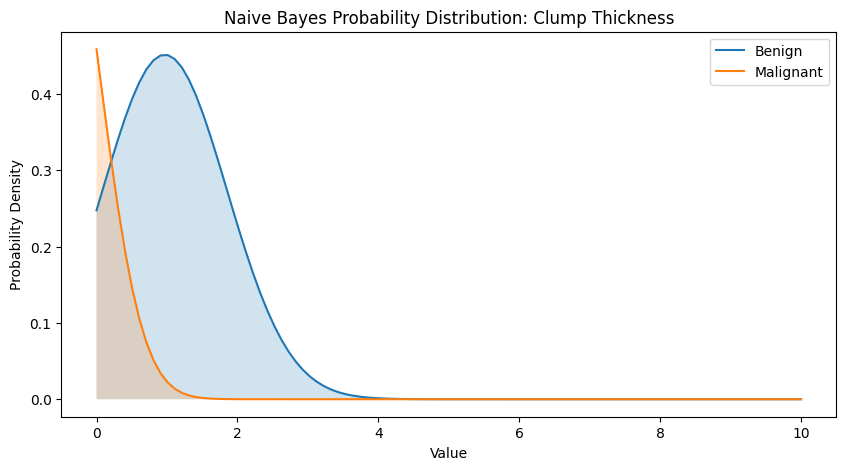

In [12]:

from scipy.stats import norm

# 1. Pick a feature index (0 = Clump Thickness)
feature_idx = 0
feature_name = 'Clump Thickness'

# 2. Get the Mean and Standard Deviation learned by the model
# Replace 'nb_model' with your Naive Bayes variable name
mean = model.theta_[:, feature_idx] # Means for each class
var = model.var_[:, feature_idx]   # Variances for each class
std = np.sqrt(var)

# 3. Plot the Bell Curves
x_axis = np.linspace(0, 10, 100)
plt.figure(figsize=(10, 5))

for i, label in enumerate(['Benign', 'Malignant']):
    plt.plot(x_axis, norm.pdf(x_axis, mean[i], std[i]), label=label)
    plt.fill_between(x_axis, norm.pdf(x_axis, mean[i], std[i]), alpha=0.2)

plt.title(f'Naive Bayes Probability Distribution: {feature_name}')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.legend()
plt.show()
